**Importing Dataset & Libraries**


*   Importing Libraries required for data preprocessing and visualization
*   Dataset of students data for analysis and insights



In [10]:
# Importing Libraries and Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# visualization style
sns.set(style="whitegrid")

# Load Dataset
df = pd.read_excel("/content/Power BI Updated Data analyst Data.xlsx")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (4894, 16)

Columns:
Index(['First Name', 'Email ID', 'Quantity', 'Events', 'Attendee Status',
       'College Name', 'How did you come to know about this event?',
       'Specify in "Others" (how did you come to know about this event)',
       'Designation', 'Year of Graduation', 'City', 'CGPA',
       'Experience with python (Months)', 'Family Income',
       'Expected salary (Lac)', 'Leadership- skills'],
      dtype='object')

First 5 rows:
  First Name           Email ID  Quantity                  Events  \
0     ANIKET     aniket@xyz.com         1  Art of Resume Building   
1  Dhanshree  dhanshree@xyz.com         1  Art of Resume Building   
2     Dhiraj     dhiraj@xyz.com         1  Art of Resume Building   
3      Pooja      pooja@xyz.com         1  Art of Resume Building   
4     Aayush     aayush@xyz.com         1  Art of Resume Building   

  Attendee Status                                       College Name  \
0       Attending  D Y PATIL INSTITUTE OF MCA AND

**Data Preprocessing**

In [11]:
# Data Cleaning

# remove duplicate rows
df = df.drop_duplicates()

# remove leading/trailing spaces in column names
df.columns = df.columns.str.strip()

# convert columns to correct types
df["CGPA"] = pd.to_numeric(df["CGPA"], errors='coerce')
df["Experience with python (Months)"] = pd.to_numeric(df["Experience with python (Months)"], errors='coerce')
df["Expected salary (Lac)"] = pd.to_numeric(df["Expected salary (Lac)"], errors='coerce')

# handle missing values
df = df.fillna(method='ffill')

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
First Name                                                         0
Email ID                                                           0
Quantity                                                           0
Events                                                             0
Attendee Status                                                    0
College Name                                                       0
How did you come to know about this event?                         0
Specify in "Others" (how did you come to know about this event)    1
Designation                                                        0
Year of Graduation                                                 0
City                                                               0
CGPA                                                               0
Experience with python (Months)                                    0
Family Income                                                      0
Expected salary (

/tmp/ipykernel_233/2411838281.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


**Basic Questions**

In [12]:
# Basic Questions

# 1. unique students
unique_students = df["Email ID"].nunique()
print("1. Unique Students:", unique_students)

# 2. average GPA
avg_gpa = df["CGPA"].mean()
print("\n2. Average GPA:", avg_gpa)

# 3. distribution across graduation years
print("\n3. Graduation Year Distribution:")
print(df["Year of Graduation"].value_counts())

# 4. distribution of python experience
print("\n4. Python Experience Distribution:")
print(df["Experience with python (Months)"].describe())

# 5. average family income
income_map = {
    "0-2 Lakh": 1,
    "2-5 Lakh": 3.5,
    "5-7 Lakh": 6,
    "7 Lakh+": 8
}

df["Family Income Numeric"] = df["Family Income"].map(income_map)
avg_income = df["Family Income Numeric"].mean()
print("\n5. Average Family Income:", avg_income, "Lakh")

# 6. GPA across colleges (Top 5)
print("\n6. GPA by College (Top 5):")

gpa_college = df.groupby("College Name")["CGPA"].mean().sort_values(ascending=False).head()
print(gpa_college)

# 7. Outliers in Quantity
print("\n7. Detecting Outliers in Quantity")

Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["Quantity"] < lower) | (df["Quantity"] > upper)]
print("Number of Outliers:", len(outliers))

# 8. Average GPA per city
print("\n8. Average GPA by City")

city_gpa = df.groupby("City")["CGPA"].mean().sort_values(ascending=False).head()
print(city_gpa)

1. Unique Students: 2157

2. Average GPA: 8.038475684511647

3. Graduation Year Distribution:
Year of Graduation
2023    1536
2024    1511
2025    1292
2026     555
Name: count, dtype: int64

4. Python Experience Distribution:
count    4894.000000
mean        5.395586
std         1.705364
min         3.000000
25%         4.000000
50%         5.000000
75%         7.000000
max         8.000000
Name: Experience with python (Months), dtype: float64

5. Average Family Income: 1.3111973845525133 Lakh

6. GPA by College (Top 5):
College Name
THAKUR INSTITUTE OF MANAGEMENT STUDIES, CAREER DEVELOPMENT & RESEARCH - [TIMSCDR]    8.585714
St Xavier's College                                                                  8.582759
B. K. Birla College of Arts, Science & Commerce (Autonomous), Kalyan                 8.456410
Symbiosis Institute of Technology, Pune                                              8.303448
AP SHAH INSTITUTE OF TECHNOLOGY                                                    


9. Correlation between Family Income and GPA
Correlation between Family Income and GPA: 0.01574077700967218 



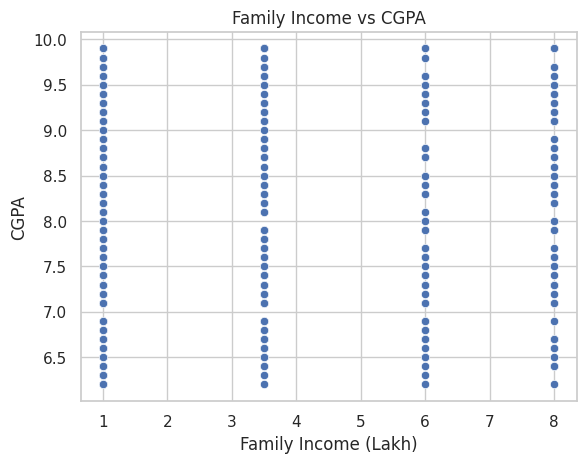

In [13]:
# 9. Relationship between Family Income and GPA
print("\n9. Correlation between Family Income and GPA")

df["Family Income Numeric"] = df["Family Income"].map(income_map)
df["Family Income Numeric"] = df["Family Income Numeric"].fillna(df["Family Income Numeric"].mean())

correlation = df["Family Income Numeric"].corr(df["CGPA"])
print("Correlation between Family Income and GPA:", correlation, "\n")

sns.scatterplot(x=df["Family Income Numeric"], y=df["CGPA"])

plt.title("Family Income vs CGPA")
plt.xlabel("Family Income (Lakh)")
plt.ylabel("CGPA")

plt.show()

**Moderate Questions**

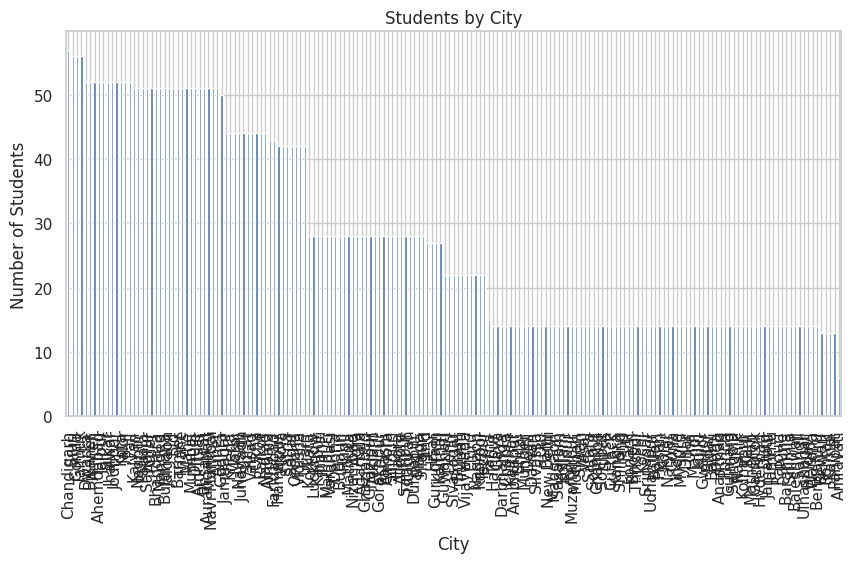

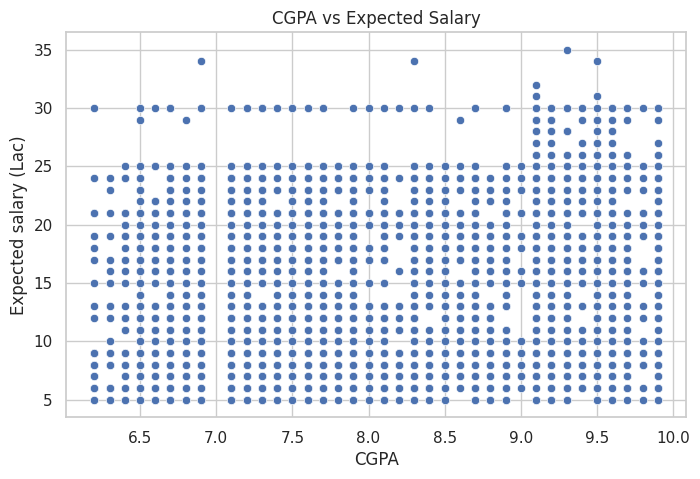


12. Event Participation
Events
Product Design & Full Stack                    842
Internship Program(IP) Success Conclave        797
Art of Resume Building                         478
Data Visualization using Power BI              455
Talk on Skill and Employability Enhancement    379
Skill and Employability Enhancement            318
IS DATA SCIENCE FOR YOU?                       306
Hello ML and DL                                262
KYC - Know Your CCPC                           205
IAC - Q&A                                      146
The SDLC & their transformations               142
Artificial Intelligence                        125
The Agile Ways of Working                      121
RPA: A Boon or A Bane                          114
Product Marketing                              112
Transformation with DevOps: The Easy Way        92
Name: count, dtype: int64

13. Leadership vs GPA
Leadership- skills
no     8.040444
no     8.034816
yes    8.036787
Name: CGPA, dtype: float64

14. Stud

In [14]:
# Moderate Questions

# 10. Students from various cities (Visualization)

plt.figure(figsize=(10,5))
df["City"].value_counts().plot(kind="bar")

plt.title("Students by City")
plt.xlabel("City")
plt.ylabel("Number of Students")
plt.show()


# 11. Expected salary vs factors

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["CGPA"],
    y=df["Expected salary (Lac)"]
)

plt.title("CGPA vs Expected Salary")
plt.show()


# 12. Event popularity

print("\n12. Event Participation")
print(df["Events"].value_counts())


# 13. Leadership vs GPA

leadership_gpa = df.groupby("Leadership- skills")["CGPA"].mean()

print("\n13. Leadership vs GPA")
print(leadership_gpa)


# 14. Students graduating by 2024

grad_2024 = df[df["Year of Graduation"] <= 2024]
print("\n14. Students graduating by 2024:", len(grad_2024))


# 15. Promotion channels

print("\n15. Promotion Channel Effectiveness")
print(df["How did you come to know about this event?"].value_counts())


# 16. Data Science event attendance

ds_students = df[df["Events"].str.contains("Data", case=False, na=False)]
print("\n16. Students attending Data Science events:", len(ds_students))


# 17. High CGPA & Python experience vs expected salary

high_group = df[(df["CGPA"] > df["CGPA"].mean()) &
                (df["Experience with python (Months)"] > df["Experience with python (Months)"].mean())]

avg_salary = high_group["Expected salary (Lac)"].mean()
print("\n17. Avg Expected Salary (High CGPA + Python Experience):", avg_salary, "LPA")


Correlation Heatmap


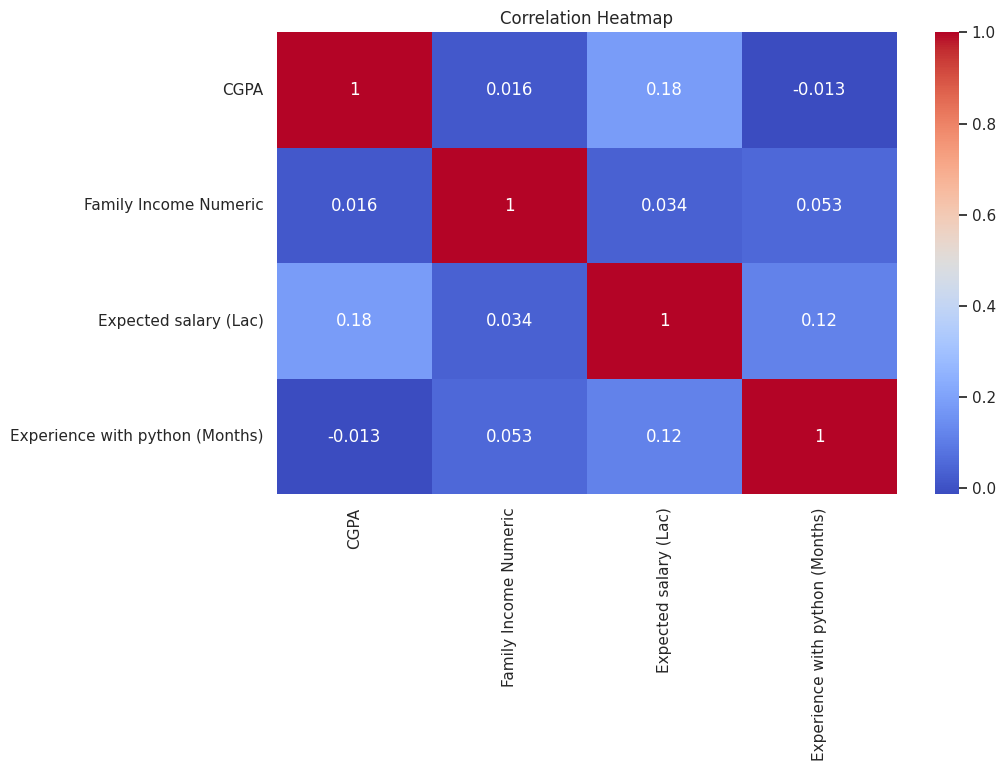

In [15]:
# Visualization – Heatmap

print("\nCorrelation Heatmap")
income_map = {
    "0-2 Lakh": 1,
    "2-5 Lakh": 3.5,
    "5-7 Lakh": 6,
    "7 Lakh+": 8
}

df["Family Income Numeric"] = df["Family Income"].map(income_map)
df["Family Income Numeric"] = df["Family Income Numeric"].fillna(df["Family Income Numeric"].mean())

plt.figure(figsize=(10,6))

corr_matrix = df[[
    "CGPA",
    "Family Income Numeric",
    "Expected salary (Lac)",
    "Experience with python (Months)"
]].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [16]:
# Processed Dataset

df.to_csv("processed_student_dataset.csv", index=False)
print("\nProcessed dataset saved successfully.")


Processed dataset saved successfully.
